Experiment 4: Implementing a Recurrent Neural Network (RNN) for
Sequence Prediction
Students will implement and train a Recurrent Neural Network (RNN) for
sequence prediction tasks, such as time series forecasting, in this experiment.


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.1097 - val_loss: 0.0389
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0285 - val_loss: 0.0077
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0078 - val_loss: 0.0028
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0065 - val_loss: 0.0021
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0046 - val_loss: 0.0040
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0048 - val_loss: 0.0027
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - val_loss: 0.0026
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0043 - val_loss: 0.0025
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - val_loss: 0.0030
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 
Test Loss: 0.0021024702582508326
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


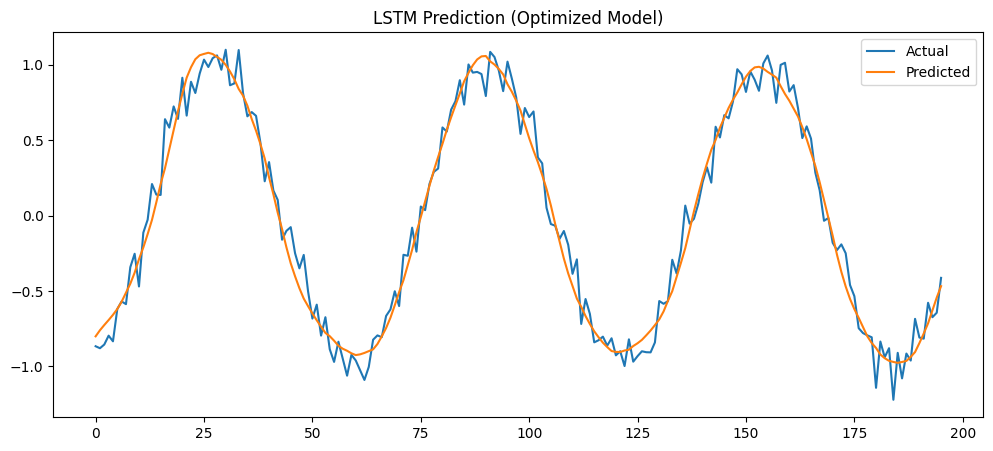

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# ==============================
# 2. Generate Data (with noise)
# ==============================
t = np.linspace(0, 100, 1000)
data = np.sin(t) + 0.1 * np.random.randn(len(t))  # realistic data

# ==============================
# 3. Normalize
# ==============================
scaler = MinMaxScaler()
data = scaler.fit_transform(data.reshape(-1,1))

# ==============================
# 4. Create Sequences
# ==============================
def create_sequences(data, time_steps=20):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X), np.array(y)

X, y = create_sequences(data, 20)

# ==============================
# 5. Train-Test Split
# ==============================
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==============================
# 6. Build Model (BEST VERSION)
# ==============================
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(20,1)),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# ==============================
# 7. Compile
# ==============================
model.compile(optimizer='adam', loss='mse')

# ==============================
# 8. Early Stopping
# ==============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ==============================
# 9. Train
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# ==============================
# 10. Evaluate
# ==============================
loss = model.evaluate(X_test, y_test)
print("Test Loss:", loss)

# ==============================
# 11. Predict
# ==============================
y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

# ==============================
# 12. Plot
# ==============================
plt.figure(figsize=(12,5))
plt.plot(y_test_inv[:200], label='Actual')
plt.plot(y_pred_inv[:200], label='Predicted')
plt.legend()
plt.title("LSTM Prediction (Optimized Model)")
plt.show()